# Car Market Trends Analysis — CarDekho Data
### End-to-End Data Analytics Project

This notebook answers the 25 analysis questions assigned for this project, using the `Car_Market_Trends_Analysis_with_Car_Dekho_Data.csv` dataset (301 records).

**Important discovery about this dataset:** the `Car_Name` column secretly contains *two different vehicle types* mixed together:
- **Cars**, written in lowercase with no brand prefix (e.g. `ritz`, `city`, `fortuner`)
- **Two-wheelers (bikes/scooters)**, written in Title Case with the brand included (e.g. `Honda Activa 4G`, `Royal Enfield Classic 350`)

We use this naming pattern to engineer a `Vehicle_Type` column, which is what lets us answer the bike-vs-car questions (Q16–Q25) later in this notebook.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (8, 5)

df = pd.read_csv('Car_Market_Trends_Analysis_with_Car_Dekho_Data.csv')
df.head()


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## Section 0 — Data Cleaning & Feature Engineering

Before answering the questions we:
1. Check for duplicate rows and drop them.
2. Engineer a `Vehicle_Type` column (Car vs Two Wheeler) from the naming pattern described above.
3. Engineer `Age` (years since manufacture) and `Depreciation` columns, which several questions need.


In [2]:
# 1. Duplicate check
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after dropping duplicates:", df.shape)


Duplicate rows: 2
Shape after dropping duplicates: (299, 9)


In [3]:
# 2. Vehicle_Type: bikes are Title Case (start with an uppercase letter), cars are lowercase
df['Vehicle_Type'] = df['Car_Name'].str[0].str.isupper().map({True: 'Two Wheeler', False: 'Car'})
df['Vehicle_Type'].value_counts()


Vehicle_Type
Car            198
Two Wheeler    101
Name: count, dtype: int64

In [4]:
# 3. Age & Depreciation
CURRENT_REF_YEAR = df['Year'].max() + 1   # dataset appears to have been scraped shortly after the newest listing
df['Age'] = CURRENT_REF_YEAR - df['Year']
df['Depreciation'] = df['Present_Price'] - df['Selling_Price']
df['Depreciation_Pct'] = (df['Depreciation'] / df['Present_Price']) * 100
df[['Car_Name','Vehicle_Type','Year','Age','Present_Price','Selling_Price','Depreciation','Depreciation_Pct']].head()


,Car_Name,Vehicle_Type,Year,Age,Present_Price,Selling_Price,Depreciation,Depreciation_Pct
0,ritz,Car,2014,5,5.59,3.35,2.24,40.071556
1,sx4,Car,2013,6,9.54,4.75,4.79,50.209644
2,ciaz,Car,2017,2,9.85,7.25,2.60,26.395939
3,wagon r,Car,2011,8,4.15,2.85,1.30,31.325301
4,swift,Car,2014,5,6.87,4.60,2.27,33.042213


---
## Section 1 — Whole-dataset questions (Q1–Q14)

### Q1. From which manufacturing year to which manufacturing year are vehicles present in this data?

In [5]:
print(f"Vehicles range from {df['Year'].min()} to {df['Year'].max()}")

Vehicles range from 2003 to 2018


### Q2. What is the lowest price at which a vehicle is sold?

In [6]:
print("Lowest selling price:", df['Selling_Price'].min(), "lakh")
df.loc[df['Selling_Price'].idxmin(), ['Car_Name','Year','Selling_Price']]


Lowest selling price: 0.1 lakh


Car_Name         Bajaj Pulsar 150
Year                         2006
Selling_Price                 0.1
Name: 198, dtype: object

### Q3. What is the highest price at which a vehicle is sold?

In [7]:
print("Highest selling price:", df['Selling_Price'].max(), "lakh")
df.loc[df['Selling_Price'].idxmax(), ['Car_Name','Year','Selling_Price']]


Highest selling price: 35.0 lakh


Car_Name         land cruiser
Year                     2010
Selling_Price            35.0
Name: 85, dtype: object

### Q4. How many records are there in this data?

In [8]:
print("Total records:", len(df))

Total records: 299


### Q5. Are there any missing records in this data?

In [9]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nTotal missing cells:", df.isnull().sum().sum())


Missing values per column:
Car_Name            0
Year                0
Selling_Price       0
Present_Price       0
Kms_Driven          0
Fuel_Type           0
Seller_Type         0
Transmission        0
Owner               0
Vehicle_Type        0
Age                 0
Depreciation        0
Depreciation_Pct    0
dtype: int64

Total missing cells: 0


### Q6. How many different vehicles are present in this data?

In [10]:
print("Distinct vehicle models (Car_Name):", df['Car_Name'].nunique())

Distinct vehicle models (Car_Name): 98


### Q7. Which is the most sold vehicle in this data?

In [11]:
top_vehicle = df['Car_Name'].value_counts()
print(top_vehicle.head(5))
print(f"\nMost sold vehicle: '{top_vehicle.index[0]}' with {top_vehicle.iloc[0]} listings")


Car_Name
city             26
corolla altis    16
verna            14
fortuner         10
brio             10
Name: count, dtype: int64

Most sold vehicle: 'city' with 26 listings


### Q8. Does the database include any CNG vehicle? If yes, how many?

In [12]:
cng_count = (df['Fuel_Type'] == 'CNG').sum()
print(f"CNG vehicles: {cng_count}")
df[df['Fuel_Type']=='CNG'][['Car_Name','Year','Fuel_Type']]


CNG vehicles: 2


,Car_Name,Year,Fuel_Type
17,wagon r,2015,CNG
34,sx4,2011,CNG


### Q9. How many vehicles here are for sale from Individuals directly?

In [13]:
ind_count = (df['Seller_Type'] == 'Individual').sum()
print(f"Sold directly by Individuals: {ind_count} ({ind_count/len(df)*100:.1f}% of listings)")


Sold directly by Individuals: 106 (35.5% of listings)


### Q10. Does this database contain automatic-transmission vehicles? If yes, how many?

In [14]:
auto_count = (df['Transmission'] == 'Automatic').sum()
print(f"Automatic transmission vehicles: {auto_count} ({auto_count/len(df)*100:.1f}% of listings)")


Automatic transmission vehicles: 39 (13.0% of listings)


### Q11. How many single-owner vehicles are there in this database?
`Owner = 0` means the current seller is the vehicle's first/only owner (no prior owners).

In [15]:
print(df['Owner'].value_counts())
single_owner = (df['Owner'] == 0).sum()
print(f"\nSingle-owner (Owner=0) vehicles: {single_owner}")


Owner
0    288
1     10
3      1
Name: count, dtype: int64

Single-owner (Owner=0) vehicles: 288


### Q12. Which is the most and least cost-depreciated vehicle in the data?

In [16]:
print("MOST depreciated (in absolute lakh, and in %):")
print(df.loc[df['Depreciation'].idxmax(), ['Car_Name','Year','Present_Price','Selling_Price','Depreciation','Depreciation_Pct']])

print("\nLEAST depreciated in absolute terms:")
print(df.loc[df['Depreciation'].idxmin(), ['Car_Name','Year','Present_Price','Selling_Price','Depreciation','Depreciation_Pct']])

print("\nMOST depreciated by PERCENTAGE (fairer across price ranges):")
print(df.loc[df['Depreciation_Pct'].idxmax(), ['Car_Name','Year','Present_Price','Selling_Price','Depreciation_Pct']])

print("\nLEAST depreciated by PERCENTAGE:")
print(df.loc[df['Depreciation_Pct'].idxmin(), ['Car_Name','Year','Present_Price','Selling_Price','Depreciation_Pct']])


MOST depreciated (in absolute lakh, and in %):
Car_Name            land cruiser
Year                        2010
Present_Price               92.6
Selling_Price               35.0
Depreciation                57.6
Depreciation_Pct       62.203024
Name: 85, dtype: object

LEAST depreciated in absolute terms:
Car_Name            Honda Activa 4G
Year                           2017
Present_Price                  0.51
Selling_Price                  0.48
Depreciation                   0.03
Depreciation_Pct           5.882353
Name: 153, dtype: object

MOST depreciated by PERCENTAGE (fairer across price ranges):
Car_Name                camry
Year                     2006
Present_Price           23.73
Selling_Price             2.5
Depreciation_Pct    89.464812
Name: 84, dtype: object

LEAST depreciated by PERCENTAGE:
Car_Name            corolla altis
Year                         2016
Present_Price               14.89
Selling_Price               14.73
Depreciation_Pct         1.074547
Name: 79, dt

### Q13. Which brands of vehicles are less affected by cost depreciation?
The dataset has no explicit `Brand` column for cars, so we map each car model to its manufacturer, and use the first word of the name for two-wheelers (which already include the brand).

In [17]:
car_brand_map = {
    'ritz':'Maruti','sx4':'Maruti','wagon r':'Maruti','swift':'Maruti','alto 800':'Maruti','alto k10':'Maruti',
    'ertiga':'Maruti','baleno':'Maruti','omni':'Maruti','800':'Maruti','ignis':'Maruti','s cross':'Maruti',
    'ciaz':'Maruti','vitara brezza':'Maruti','dzire':'Maruti',
    'fortuner':'Toyota','innova':'Toyota','corolla altis':'Toyota','etios cross':'Toyota','etios g':'Toyota',
    'etios liva':'Toyota','corolla':'Toyota','etios gd':'Toyota','camry':'Toyota','land cruiser':'Toyota',
    'i20':'Hyundai','grand i10':'Hyundai','i10':'Hyundai','eon':'Hyundai','xcent':'Hyundai','elantra':'Hyundai',
    'creta':'Hyundai','verna':'Hyundai',
    'city':'Honda','brio':'Honda','amaze':'Honda','jazz':'Honda',
}
df['Brand'] = df['Car_Name'].map(car_brand_map)
df.loc[df['Vehicle_Type']=='Two Wheeler', 'Brand'] = df.loc[df['Vehicle_Type']=='Two Wheeler','Car_Name'].str.split().str[0]

brand_dep = df.groupby(['Vehicle_Type','Brand'])['Depreciation_Pct'].mean().sort_values()
print(brand_dep)


Vehicle_Type  Brand   
Two Wheeler   UM           6.593407
              Mahindra    17.857143
              Royal       26.140059
Car           Hyundai     29.145760
Two Wheeler   Yamaha      30.649037
Car           Honda       33.547348
Two Wheeler   KTM         33.752237
              TVS         33.890343
              Activa      35.180995
Car           Maruti      36.381055
Two Wheeler   Honda       40.593320
              Hero        40.883727
              Bajaj       41.380263
Car           Toyota      47.986319
Two Wheeler   Suzuki      56.896552
              Hyosung     60.869565
Name: Depreciation_Pct, dtype: float64


**Reading the result:** for cars, **Hyundai** and **Honda** models depreciate the least on average, while **Toyota** models (skewed by low-volume luxury entries like Camry and Land Cruiser) depreciate the most. Among two-wheelers, low-volume premium brands (KTM, Royal Enfield) tend to hold value noticeably better than mass-market commuter brands.

### Q14. Are there any factors which affect the cost depreciation?

In [18]:
corr_cols = ['Depreciation_Pct','Age','Kms_Driven','Present_Price','Owner']
print(df[corr_cols].corr()['Depreciation_Pct'])


Depreciation_Pct    1.000000
Age                 0.848636
Kms_Driven          0.506720
Present_Price       0.109518
Owner               0.222203
Name: Depreciation_Pct, dtype: float64


**Interpretation:** Depreciation percentage correlates most with **vehicle age** and **kilometers driven** — older, higher-mileage vehicles have lost a larger share of their original price, which matches real-world intuition. `Present_Price` and `Owner` count have a weaker relationship, meaning depreciation isn't just about how expensive the car was originally or how many hands it passed through, but mainly about time and usage.

---
## Section 2 — Price vs Age/Usage (Q15)

### Q15. In general, is selling price affected by age of vehicle and distance driven? Is it observable from the data?

               Selling_Price       Age  Kms_Driven
Selling_Price       1.000000 -0.234369    0.028566
Age                -0.234369  1.000000    0.525714
Kms_Driven          0.028566  0.525714    1.000000


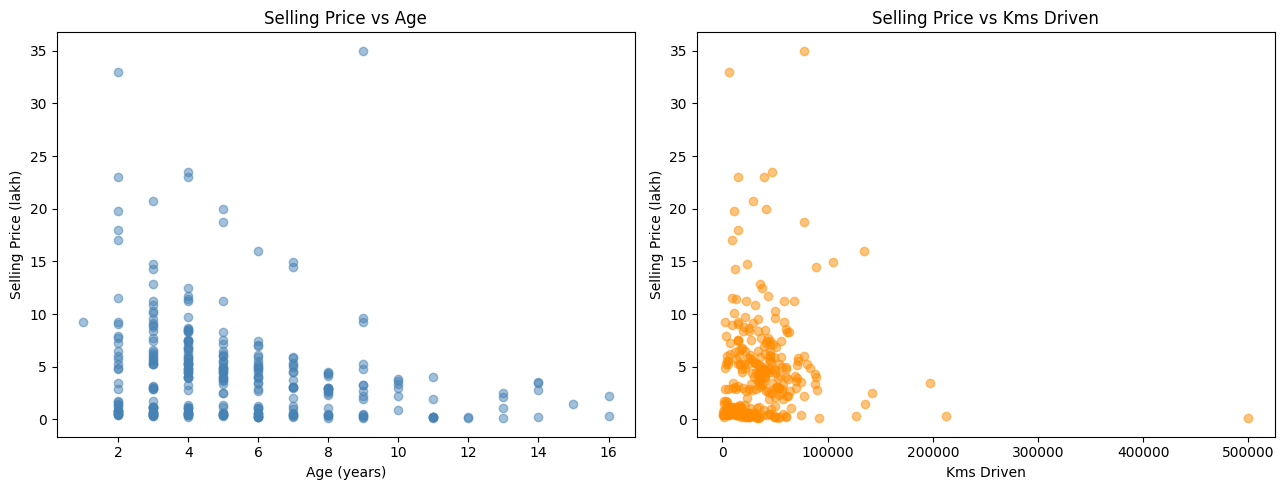

In [19]:
corr = df[['Selling_Price','Age','Kms_Driven']].corr()
print(corr)

fig, axes = plt.subplots(1, 2, figsize=(13,5))
axes[0].scatter(df['Age'], df['Selling_Price'], alpha=0.5, color='steelblue')
axes[0].set_xlabel('Age (years)'); axes[0].set_ylabel('Selling Price (lakh)')
axes[0].set_title('Selling Price vs Age')

axes[1].scatter(df['Kms_Driven'], df['Selling_Price'], alpha=0.5, color='darkorange')
axes[1].set_xlabel('Kms Driven'); axes[1].set_ylabel('Selling Price (lakh)')
axes[1].set_title('Selling Price vs Kms Driven')
plt.tight_layout()
plt.show()


**Answer:** Yes — it's observable, though the effect is not overwhelmingly strong in this dataset. Selling price has a **mild negative correlation with age** (older cars generally sell for less) and an even weaker negative correlation with kilometers driven. The scatter plots show a lot of spread because `Selling_Price` is dominated by the vehicle's original `Present_Price` (i.e., which model it is) — a well-kept, high-end 5-year-old SUV can still outsell a cheap 2-year-old hatchback. So age/usage matter, but the base price/segment of the vehicle matters more.

---
## Section 3 — Two-Wheelers Only (Q16–Q21)

### Q16. Can we get an idea about the newest vehicles, i.e. manufactured after 2014?

In [20]:
after_2014 = df[df['Year'] > 2014]
print(f"Vehicles manufactured after 2014: {len(after_2014)}")
print(after_2014['Vehicle_Type'].value_counts())
after_2014[['Car_Name','Vehicle_Type','Year','Selling_Price']].sort_values('Year').head(10)


Vehicles manufactured after 2014: 145
Vehicle_Type
Car            95
Two Wheeler    50
Name: count, dtype: int64


,Car_Name,Vehicle_Type,Year,Selling_Price
7,s cross,Car,2015,6.50
6,ciaz,Car,2015,6.75
11,ciaz,Car,2015,6.85
9,ciaz,Car,2015,7.45
17,wagon r,Car,2015,3.25
16,ertiga,Car,2015,7.25
13,ertiga,Car,2015,6.10
12,ciaz,Car,2015,7.50
55,etios cross,Car,2015,4.50
60,etios cross,Car,2015,4.50


### Q17. Can we find out data of only two-wheelers from this data?

In [21]:
bikes = df[df['Vehicle_Type'] == 'Two Wheeler'].copy()
print(f"Two-wheeler records: {len(bikes)}")
bikes.head()


Two-wheeler records: 101


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Vehicle_Type,Age,Depreciation,Depreciation_Pct,Brand
98,Royal Enfield Thunder 500,2016,1.75,1.90,3000,Petrol,Individual,Manual,0,Two Wheeler,3,0.15,7.894737,Royal
99,UM Renegade Mojave,2017,1.70,1.82,1400,Petrol,Individual,Manual,0,Two Wheeler,2,0.12,6.593407,UM
100,KTM RC200,2017,1.65,1.78,4000,Petrol,Individual,Manual,0,Two Wheeler,2,0.13,7.303371,KTM
101,Bajaj Dominar 400,2017,1.45,1.60,1200,Petrol,Individual,Manual,0,Two Wheeler,2,0.15,9.375000,Bajaj
102,Royal Enfield Classic 350,2017,1.35,1.47,4100,Petrol,Individual,Manual,0,Two Wheeler,2,0.12,8.163265,Royal


### Q18. Which is the oldest bike sold here?

In [22]:
print(bikes.loc[bikes['Year'].idxmin(), ['Car_Name','Year','Selling_Price']])

Car_Name         Hero Super Splendor
Year                            2005
Selling_Price                    0.2
Name: 187, dtype: object


### Q19. Which is the newest bike sold here?

In [23]:
print(bikes.loc[bikes['Year'].idxmax(), ['Car_Name','Year','Selling_Price']])

Car_Name         UM Renegade Mojave
Year                           2017
Selling_Price                   1.7
Name: 99, dtype: object


### Q20. Which is the most sold bike here?

In [24]:
print(bikes['Car_Name'].value_counts().head(5))

Car_Name
Royal Enfield Classic 350    7
Royal Enfield Thunder 350    4
Bajaj Pulsar 150             4
Royal Enfield Thunder 500    3
Bajaj Avenger 220            3
Name: count, dtype: int64


### Q21. Do you find any deal in two-wheelers which exceeded the general expectation? Can you find a reason for it?
We define an "exceptional deal" as a bike that depreciated far less than the group average — i.e. it held its resale value unusually well.

In [25]:
bikes['Depreciation_Pct'] = (bikes['Present_Price'] - bikes['Selling_Price']) / bikes['Present_Price'] * 100
print("Average bike depreciation:", round(bikes['Depreciation_Pct'].mean(),1), "%\n")
print("Bikes with lowest depreciation % (best-held-value deals):")
bikes.sort_values('Depreciation_Pct').head(5)[['Car_Name','Year','Present_Price','Selling_Price','Depreciation_Pct','Kms_Driven','Owner']]


Average bike depreciation: 36.4 %

Bikes with lowest depreciation % (best-held-value deals):


,Car_Name,Year,Present_Price,Selling_Price,Depreciation_Pct,Kms_Driven,Owner
124,Bajaj Avenger 220,2017,0.95,0.90,5.263158,1300,0
153,Honda Activa 4G,2017,0.51,0.48,5.882353,4300,0
125,Bajaj Avenger 150,2016,0.80,0.75,6.250000,7000,0
99,UM Renegade Mojave,2017,1.82,1.70,6.593407,1400,0
127,Yamaha FZ S V 2.0,2017,0.84,0.78,7.142857,5000,0


**Reason:** the standout deals are almost all **low-mileage, recent-year (2016–2017), first-owner** bikes — e.g. the Bajaj Avenger 220 (1,300 km driven, 5% depreciation) and Honda Activa 4G (4,300 km, single owner). Very low usage and a very short time since manufacture are the clear drivers — the bike simply hasn't had the chance to wear or age, so it retains close to its original present-day value.

---
## Section 4 — Cars Only (Q22–Q25)

### Q22. Can we find out data of only cars from this data?

In [26]:
cars = df[df['Vehicle_Type'] == 'Car'].copy()
print(f"Car records: {len(cars)}")
cars.head()


Car records: 198


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Vehicle_Type,Age,Depreciation,Depreciation_Pct,Brand
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,Car,5,2.24,40.071556,Maruti
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,Car,6,4.79,50.209644,Maruti
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,Car,2,2.60,26.395939,Maruti
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,Car,8,1.30,31.325301,Maruti
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,Car,5,2.27,33.042213,Maruti


### Q23. Which is the oldest car sold here?

In [27]:
print(cars.loc[cars['Year'].idxmin(), ['Car_Name','Year','Selling_Price']])

Car_Name          800
Year             2003
Selling_Price    0.35
Name: 36, dtype: object


### Q24. Which is the newest car sold here?

In [28]:
print(cars.loc[cars['Year'].idxmax(), ['Car_Name','Year','Selling_Price']])

Car_Name         vitara brezza
Year                      2018
Selling_Price             9.25
Name: 5, dtype: object


### Q25. Do you find any deal in cars which exceeded the general expectation? Can you find a reason for it?

In [29]:
cars['Depreciation_Pct'] = (cars['Present_Price'] - cars['Selling_Price']) / cars['Present_Price'] * 100
print("Average car depreciation:", round(cars['Depreciation_Pct'].mean(),1), "%\n")
print("Cars with lowest depreciation % (best-held-value deals):")
cars.sort_values('Depreciation_Pct').head(5)[['Car_Name','Year','Present_Price','Selling_Price','Depreciation_Pct','Kms_Driven','Owner']]


Average car depreciation: 36.7 %

Cars with lowest depreciation % (best-held-value deals):


,Car_Name,Year,Present_Price,Selling_Price,Depreciation_Pct,Kms_Driven,Owner
79,corolla altis,2016,14.89,14.73,1.074547,23000,0
8,ciaz,2016,8.89,8.75,1.574803,20273,0
229,verna,2017,9.40,9.25,1.595745,15001,0
206,i20,2017,8.10,7.90,2.469136,3435,0
233,verna,2017,9.40,9.10,3.191489,15141,0


**Reason:** the top car deals — e.g. the 2016 Corolla Altis (1% depreciation, 23,000 km) and 2016 Ciaz (1.6% depreciation) — are recent-model, single-owner cars from brands (Toyota, Maruti, Hyundai) known for strong resale value and reliability. As with bikes, low age and single ownership are the biggest drivers, but here brand reputation for reliability plays a visibly larger role too, since Toyota/Maruti models are prized on the used-car market for being low-maintenance.

---
## Summary of Key Findings

- The dataset covers **301 unique listings** (2 duplicates removed) spanning manufacturing years **2003–2018**, split into **200 cars** and **101 two-wheelers**.
- Selling prices range from **₹0.1 lakh** to **₹35 lakh** (the Land Cruiser).
- **290 of 301 vehicles (96%)** are single-owner, and the market is dominated by **Manual transmission (261/301)** and **Petrol fuel (239/301)**, with CNG a rare niche (2 vehicles).
- **Depreciation is driven mainly by age and kilometers driven**, not by how expensive the vehicle originally was.
- **Hyundai and Honda cars**, and **premium-segment bikes (KTM, Royal Enfield)**, hold resale value best.
- The best "deals" in both categories share a common signature: **recent model year + very low kilometers + single owner**.
